# Alignment of HAADF images with SOFIMA

In [2]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from EDX import *
from utils import *
from utils_sofima import *
import numpy as np
import hyperspy.api as hs
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import copy
from importlib import reload

from skimage import data, img_as_float, feature
import tensorstore as ts
from scipy.stats import pearsonr
from datetime import datetime
import warnings
import pickle
from datetime import datetime
import gc


%load_ext autoreload
%autoreload 2

#### Allignment settings 

In [4]:
num_frames = 100
suffix = '_100frames_align2zero'

# load data
file_path = "../data/EMD/EDXdataset.emd"

#### Load haadf stack

In [5]:
# load and preprocess
EXD_summed_unaligned, haadf_stack, _ = load_EDX(file_path, first_frame=0, last_frame=num_frames, sum_frames=True, haadf_last_frame=False)

print(haadf_stack.shape)
print(haadf_stack.max(),haadf_stack.dtype)

WARNING | RosettaSciIO | The file contains only one spectrum stream (rsciio.emd._emd_velox:590)
(100, 2048, 2048)
65535.0 float64


#### Align based on the first 20 HAADf images - or 100 (for validation)

In [ ]:
# load presaved
#import dill as pickle
#with open(f"results/sofima_transforms/20260109_130147_sof_object_100frames.pkl", "rb") as f:
#    sof_obj = pickle.load(f)


In [ ]:
sof_obj = get_alignment(haadf_stack, 
                  n_align = num_frames,
                  min_peak_ratio=1.1, 
                  min_peak_sharpness=1.1,
                  max_magnitude=0, 
                  max_deviation=0,
                  patch_size = 100,
                  stride = 25,
                  pad_remove = 50,
                  align_to_zero = True)


#### Apply the alignment 

In [6]:
haadf_stack_aligned = apply_alignment_2D(haadf_stack, sof_obj, 'uint8')

  0%|          | 0/99 [00:00<?, ?it/s]

#### Evaluate alignment performance (PCC between frames, before and after: can add other metrics later)

In [7]:
print(haadf_stack.shape, haadf_stack_aligned.shape)
print(haadf_stack.dtype, haadf_stack_aligned.dtype)

# make sure the stacks have matched dimensions
pad_remove = sof_obj.pad_remove
haadf_stack = np.transpose(haadf_stack,[1,2,0])[pad_remove:2048-pad_remove,pad_remove:2048-pad_remove, :num_frames].astype('uint8')

print(haadf_stack.shape, haadf_stack_aligned.shape)
print(haadf_stack.dtype, haadf_stack_aligned.dtype)

(100, 2048, 2048) (1948, 1948, 100)
float64 uint8
(1948, 1948, 100) (1948, 1948, 100)
uint8 uint8


In [8]:
pcc_before, pcc_after = eval_alignment(haadf_stack, haadf_stack_aligned)
print('Pearson coeffients before and after: ', np.mean(pcc_before), np.mean(pcc_after))

Pearson coeffients before and after:  0.7241205731442077 0.8991672930002682


### The "summed" haadfs comparison (to illustrate the blurring effect)

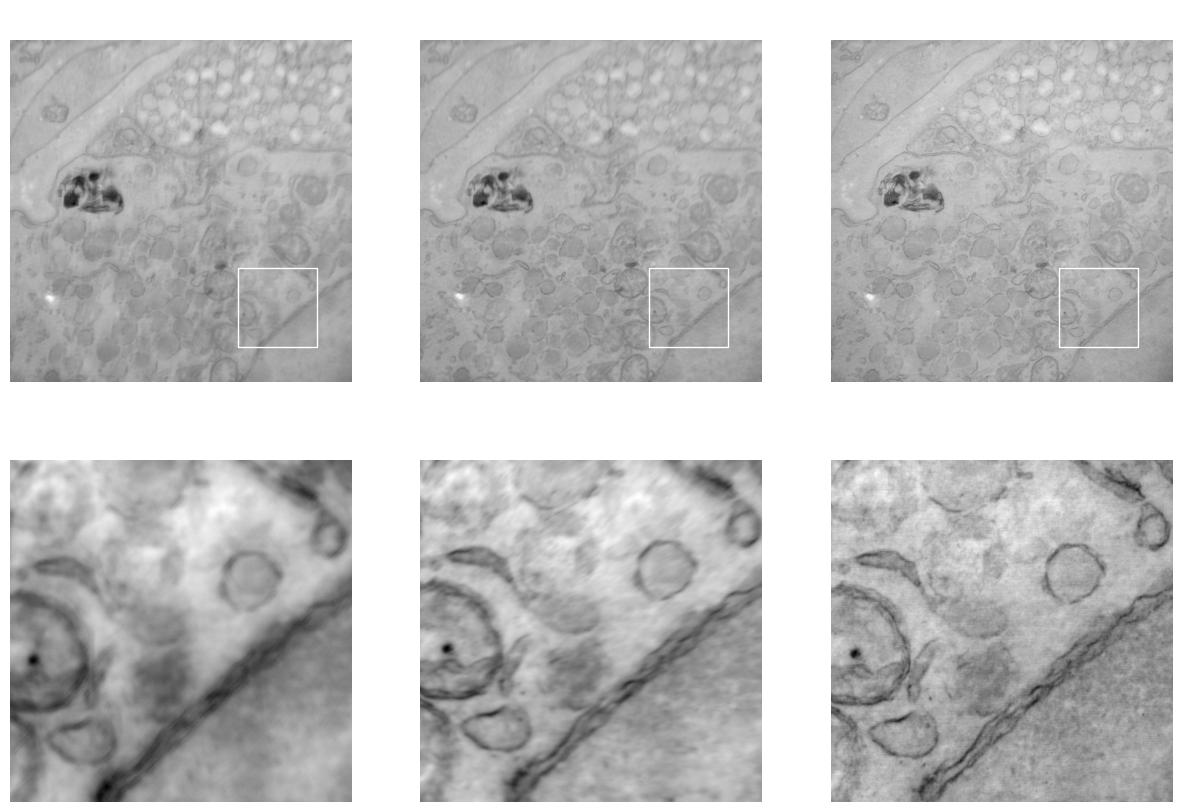

In [28]:
zoom = (slice(1300,1750),slice(1300,1750))

f, ax = plt.subplots(2,3,figsize=(15,10))
ax[0][0].imshow(haadf_stack[:,:,:100].sum(axis=2),cmap='gray_r')
ax[0][1].imshow(haadf_stack_aligned[:,:,:100].sum(axis=2),cmap='gray_r')
ax[0][2].imshow(haadf_stack[:,:,-1],cmap='gray_r')

ax[0][0].set_title('Unaligned',fontsize=20)
ax[0][1].set_title('Aligned',fontsize=20)
ax[0][2].set_title('Single frame',fontsize=20)

ax[1][0].imshow(haadf_stack.sum(axis=2)[zoom],cmap='gray_r')
ax[1][1].imshow(haadf_stack_aligned.sum(axis=2)[zoom],cmap='gray_r')
ax[1][2].imshow(haadf_stack[:,:,-1][zoom],cmap='gray_r')


 # Extract rectangle from zoom slices
ys, xs = zoom
y0 = ys.start or 0
y1 = ys.stop or haadf_stack[:,:,:20].sum(axis=2).shape[0]
x0 = xs.start or 0
x1 = xs.stop or haadf_stack_aligned[:,:,:20].sum(axis=2).shape[1]


ax[0][0].add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                      linewidth=1, edgecolor='white', facecolor='none'))
ax[0][1].add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                      linewidth=1, edgecolor='white', facecolor='none'))
ax[0][2].add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                      linewidth=1, edgecolor='white', facecolor='none'))

for a in ax.ravel():
    a.axis('off')

make_dark_presentation(f,text_color='white', line_width=2.5, transparent=True)
plt.savefig("/Users/aj/Desktop/WIPfigures/blur_haadf.png", dpi=300, transparent=True)

#### Visualize the aligned images

In [ ]:
# output folder

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
outdir = f"results/alignments/{timestamp+suffix}"
os.makedirs(outdir, exist_ok=True)

zoom = (slice(600,1050),slice(250,700))

for i in range(haadf_stack.shape[2]):
    f, ax = plt.subplots(2, 2, figsize=(10, 10))

    # Right (aligned)
    ax[0][1].imshow(haadf_stack_aligned[:, :, i], cmap="gray_r")
    ax[0][1].set_title(f"Frame {i:d} corr w/ frame 0: {pcc_after[i]:.3f}")
    ax[0][1].axis("off")

    # Left (unaligned)
    ax[0][0].imshow(haadf_stack[:, :, i], cmap="gray_r")
    ax[0][0].set_title(f"Frame {i:d} corr with frame 0: {pcc_before[i]:.3f}")
    ax[0][0].axis("off")


    # inset
    # Right (aligned)
    ax[1][1].imshow(haadf_stack_aligned[:, :, i][zoom], cmap="gray_r")
    ax[1][1].axis("off")

    # Left (unaligned)
    ax[1][0].imshow(haadf_stack[:, :, i][zoom], cmap="gray_r")
    ax[1][0].axis("off")

    # Extract rectangle from zoom slices
    ys, xs = zoom
    y0 = ys.start or 0
    y1 = ys.stop or haadf_stack_aligned[:, :, i].shape[0]
    x0 = xs.start or 0
    x1 = xs.stop or haadf_stack_aligned[:, :, i].shape[1]



    ax[0][0].add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                          linewidth=1, edgecolor='white', facecolor='none'))
    ax[0][1].add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                          linewidth=1, edgecolor='white', facecolor='none'))

    
    # Save figure
    outfile = os.path.join(outdir, f"slice_{i:03d}.png")
    #plt.savefig(outfile, dpi=150, bbox_inches="tight")
    #plt.close(fig)

    make_dark_presentation(f,text_color='white', line_width=2.5, transparent=True)
    plt.savefig(outfile, dpi=300, transparent=True)

print(f"Saved alignment figures to: {outdir}")


#### Save the alignment transformation

In [ ]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
with open(f"results/sofima_transforms/{timestamp}_sof_object{suffix}.pkl", "wb") as f:
    pickle.dump(sof_obj, f)


#### Load the alignment 

In [3]:
import dill as pickle
with open(f"results/sofima_transforms/20260109_130147_sof_object_100frames.pkl", "rb") as f:
    sof_obj = pickle.load(f)


### Apply to the EDX cube

#### 1) TensorStore the unaligned EDX frames (this takes long)

In [4]:
import logging
logging.getLogger("rsciio.emd").setLevel(logging.ERROR)
tmp = store_unaligned_hsi_alt(file_path,'tmp/unaligned_hsi'+suffix,n_frames=num_frames)

### Create two EDX objects, one aligned, one not

#### load data from EMD

In [6]:
edx_unaligned, haadf, xray_energies = load_EDX(file_path, first_frame=0, last_frame=num_frames, sum_frames=True, haadf_last_frame= False)

#### Unaligned

In [7]:
tile_1 = EM_EDX(haadf[0,:,:], edx_unaligned, xray_energies)
tile_1.apply("crop", parameters={"crop_idx": (slice(None), slice(None), slice(96, 4096))})
tile_1.apply("binning", parameters={"dim": (2048, 2048, 250)})
#tile_1.apply("MeanFilterEDX", parameters={"kernel_size": 3})

<EM_EDX | 2 steps logged>

#### Aligned

In [ ]:
pad_remove = sof_obj.pad_remove
tile_2 = EM_EDX(haadf[0,:,:], edx_unaligned, xray_energies)
tile_2.apply("crop", parameters={"crop_idx": (slice(None), slice(None), slice(96, 4096))})
tile_2.apply("binning", parameters={"dim": (2048, 2048, 250)})


In [ ]:
# Align
tile_2.apply("sofima_align", parameters={"hsi_stack_path": "tmp/unaligned_hsi_100frames", "alignment": sof_obj, "data_type": "float32",
                                        "save_aligned": False, "hsi_stack_aligned_path": "tmp/aligned_hsi"+suffix})   


#### Save an aligned tile to memory

In [11]:
# save to memory
import pickle
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
with open(f"results/preprocessed_edx/{timestamp}_tile_aligned{suffix}.pkl", "wb") as f:
    pickle.dump(tile_2, f)



#### load the above

In [ ]:
with open('results/preprocessed_edx/20251201_142554_tile_aligned.pkl', 'rb') as file:
    tile_2 = pickle.load(file)

tile_2.summary()

### Exporting HAADF for additional annotation

In [ ]:
#import tifffile as tf
#tf.imwrite('/Users/aj/Desktop/haadf_00.tiff', Normalize_uint8(1-binning_xy(haadf_stack[0,:,:])))
#tf.imwrite('/Users/aj/Desktop/haadf_19.tiff', Normalize_uint8(1-binning_xy(haadf_stack[19,:,:])))
#tf.imwrite('/Users/aj/Desktop/haadf_99.tiff', Normalize_uint8(1-binning_xy(haadf_stack[99,:,:])))